In [1]:
import os
import json
import copy
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm, trange
import numpy as np
from torch.utils.data.sampler import SubsetRandomSampler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F
from itertools import cycle

In [2]:
DATA_DIR = "../data/combined-dataset-16class"
WEIGHTS_PATH = f"{DATA_DIR}/class_weights.json"
BATCH_SIZE = 32
NUM_CLASSES = 16
NUM_EPOCHS = 30
LEARNING_RATE = 0.001
APPLY_NOISE = False 
MODEL_NAME = "densenet_201"

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

Training on device: cuda


In [4]:
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.05):
        self.std = std
        self.mean = mean
    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

# DEFINE TRANSFORMS

In [5]:
train_transform_list = [
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]

In [6]:
if APPLY_NOISE:
    train_transform_list.append(AddGaussianNoise(mean=0.0, std=0.05))
train_transform = transforms.Compose(train_transform_list)

In [7]:
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
train_dataset = datasets.ImageFolder(root=f"{DATA_DIR}/train", transform=train_transform)
val_dataset = datasets.ImageFolder(root=f"{DATA_DIR}/train", transform=eval_transform)

In [9]:
validation_split = 0.2
dataset_size = len(train_dataset)
indices = list(range(dataset_size))
split = int(np.floor(validation_split * dataset_size))

In [10]:
np.random.seed(42)
np.random.shuffle(indices)
train_indices, val_indices = indices[split:], indices[:split]

In [11]:
train_sampler = SubsetRandomSampler(train_indices)
val_sampler = SubsetRandomSampler(val_indices)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, sampler=val_sampler, num_workers=4, pin_memory=True)

In [13]:
class_names = train_dataset.classes
print(f"Total training directory images: {dataset_size}")
print(f"Dynamically split into -> Train: {len(train_indices)} | Validation: {len(val_indices)}")

Total training directory images: 2459
Dynamically split into -> Train: 1968 | Validation: 491


# Load pre-trained DenseNet-201

In [14]:
model = models.densenet201(weights=models.DenseNet201_Weights.IMAGENET1K_V1)

# Modify the final layer (DenseNet uses 'classifier' directly)
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)
print("DenseNet201 initialized and moved to GPU.")

Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /home/jagujay/.cache/torch/hub/checkpoints/densenet201-c1103571.pth
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 77.4M/77.4M [00:02<00:00, 31.9MB/s]


DenseNet201 initialized and moved to GPU.


In [15]:
with open(WEIGHTS_PATH, "r") as f:
    weight_dict = json.load(f)

weights_list = [weight_dict[c] for c in class_names]
class_weights_tensor = torch.tensor(weights_list, dtype=torch.float32).to(device)

In [16]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [17]:
patience = 5
best_loss = float('inf')
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

In [18]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [19]:
start_time = time.time()

epoch_pbar = trange(NUM_EPOCHS, desc="Overall Progress", unit="epoch")

for epoch in epoch_pbar:
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
        else:
            model.eval()
            dataloader = val_loader

        running_loss = 0.0
        running_corrects = 0

        batch_pbar = tqdm(dataloader, desc=f"Epoch {epoch+1} [{phase.capitalize()}]", leave=False)

        for inputs, labels in batch_pbar:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            batch_pbar.set_postfix({'batch_loss': f"{loss.item():.4f}"})

        # Calculate epoch-level metrics
        dataset_size = len(dataloader.sampler)
        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        if phase == 'train':
            train_losses.append(epoch_loss)
            train_accs.append(epoch_acc.item())
        else:
            val_losses.append(epoch_loss)
            val_accs.append(epoch_acc.item())
            
            tqdm.write(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
                       f"Train Loss: {train_losses[-1]:.4f} Acc: {train_accs[-1]:.4f} | "
                       f"Val Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if epoch_loss < best_loss:
                best_loss = epoch_loss
                best_model_wts = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

    if patience_counter >= patience:
        tqdm.write(f"Early stopping triggered at epoch {epoch+1}!")
        break

time_elapsed = time.time() - start_time
print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')

Overall Progress:   0%|          | 0/30 [00:00<?, ?epoch/s]

Epoch 1 [Train]:   0%|          | 0/62 [00:00<?, ?it/s]

Epoch 1 [Val]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 1/30 | Train Loss: 2.5485 Acc: 0.1890 | Val Loss: 10.0919 Acc: 0.1324


Epoch 2 [Train]:   0%|          | 0/62 [00:00<?, ?it/s]

...

Epoch 17 [Val]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 17/30 | Train Loss: 1.3865 Acc: 0.5030 | Val Loss: 1.7956 Acc: 0.4155


Epoch 18 [Train]:   0%|          | 0/62 [00:00<?, ?it/s]

Epoch 18 [Val]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 18/30 | Train Loss: 1.2985 Acc: 0.5193 | Val Loss: 1.7848 Acc: 0.4318
Early stopping triggered at epoch 18!

Training complete in 154m 17s


In [20]:
model.load_state_dict(best_model_wts)
os.makedirs("../models", exist_ok=True)
os.makedirs(f"../models/{MODEL_NAME}", exist_ok=True)
torch.save(model.state_dict(), f"../models/{MODEL_NAME}/{MODEL_NAME}_best.pth")
print(f"Best model saved to ../models/{MODEL_NAME}/{MODEL_NAME}_best.pth")

Best model saved to ../models/densenet_201/densenet_201_best.pth


# TESTING

In [21]:
MODEL_WEIGHTS_PATH = f"../models/{MODEL_NAME}/{MODEL_NAME}_best.pth"

print(f"Evaluating on device: {device}")
sns.set_theme(style="whitegrid")

Evaluating on device: cuda


In [22]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [23]:
test_dataset = datasets.ImageFolder(root=f"{DATA_DIR}/test", transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [24]:
class_names = test_dataset.classes
print(f"Loaded {len(test_dataset)} test images across {len(class_names)} classes.")

Loaded 322 test images across 16 classes.


In [25]:
def load_trained_model(model_name, num_classes, weights_path, device):
    """Initializes the architecture and loads saved weights."""
    if model_name == 'resnet_50':
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        
    elif model_name == 'effnet_b0':
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        
    elif model_name == 'effnet_b3':
        model = models.efficientnet_b3(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        
    elif model_name == 'densenet_201':
        model = models.densenet201(weights=None)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    else:
        raise ValueError(f"Unknown model architecture: {model_name}")

    model.load_state_dict(torch.load(weights_path, map_location=device))
    model = model.to(device)
    model.eval()
    return model

In [26]:
model = load_trained_model(MODEL_NAME, NUM_CLASSES, MODEL_WEIGHTS_PATH, device)
print(f"Successfully loaded {MODEL_NAME} weights from disk.")

/tmp/ipykernel_38389/36944534.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path, map_location=device))


Successfully loaded densenet_201 weights from disk.


In [27]:
def evaluate_model(model, dataloader, classes, device):
    all_preds = []
    all_labels = []
    all_probs = []
    
    print("Generating predictions...")
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # 1. Print Classification Report
    print("\n" + "="*50)
    print(f"CLASSIFICATION REPORT: {MODEL_NAME.upper()}")
    print("="*50)
    report_text = classification_report(all_labels, all_preds, target_names=classes, digits=4)
    print(report_text)

    os.makedirs("../visualizations", exist_ok=True)
    os.makedirs(f"../visualizations/{MODEL_NAME}", exist_ok=True)
    with open(f"../visualizations/{MODEL_NAME}/report.txt", "w") as f:
        f.write(f"Classification Report for {MODEL_NAME.upper()}\n\n")
        f.write(report_text)
        
    report_dict = classification_report(all_labels, all_preds, target_names=classes, output_dict=True)
    df_report = pd.DataFrame(report_dict).transpose()
    df_report.to_csv(f"../visualizations/{MODEL_NAME}/report.csv")
    print(f"Metrics saved to ../visualizations/{MODEL_NAME}/report.csv")
    
    # 2. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes,
                cbar_kws={'label': 'Number of Images'})
    
    plt.title(f'Confusion Matrix: {MODEL_NAME.upper()}', fontsize=16, pad=20)
    plt.ylabel('True Label', fontsize=12, labelpad=10)
    plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"../visualizations/{MODEL_NAME}/confusion_matrix.png", dpi=300, bbox_inches='tight')
    plt.show()

    n_classes = len(classes)
    y_bin = label_binarize(all_labels, classes=range(n_classes))
    all_probs = np.array(all_probs)
    
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
    # --- PLOTTING THE ROC CURVE ---
    plt.figure(figsize=(12, 10))
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow', 'brown', 'pink', 'gray', 'olive', 'lime', 'teal', 'navy', 'maroon'])
    
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC curve of {0} (area = {1:0.2f})'.format(classes[i], roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=2) # Diagonal guessing line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.title(f'Multi-Class ROC Curve: {MODEL_NAME.upper()}', fontsize=16)
    
    # Put legend outside the plot so it doesn't cover the lines
    plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=10)
    plt.tight_layout()
    
    plt.savefig(f"../visualizations/{MODEL_NAME}/{MODEL_NAME}_roc_curve.png", dpi=300, bbox_inches='tight')
    plt.show()

Generating predictions...

CLASSIFICATION REPORT: DENSENET_201
                            precision    recall  f1-score   support

                Apple Leaf     0.7083    0.8500    0.7727        20
           Apple Rust Leaf     0.7586    0.6875    0.7213        32
           Apple Scab leaf     0.6250    0.6250    0.6250        32
       Corn Gray Leaf Spot     0.5789    0.7333    0.6471        15
                 Corn Leaf     0.4500    0.8182    0.5806        11
          Corn Leaf Blight     0.6667    0.5217    0.5854        23
            Corn Rust Leaf     0.7619    0.7619    0.7619        21
        Potato Leaf Blight     0.7500    0.3333    0.4615        27
     Potato Leafroll Virus     0.5000    0.4545    0.4762        11
               Tomato Leaf     0.3810    0.4211    0.4000        19
Tomato Leaf Bacterial Spot     0.3000    0.4500    0.3600        20
  Tomato Leaf Early Blight     0.3158    0.6000    0.4138        20
   Tomato Leaf Late Blight     0.5200    0.6190    0

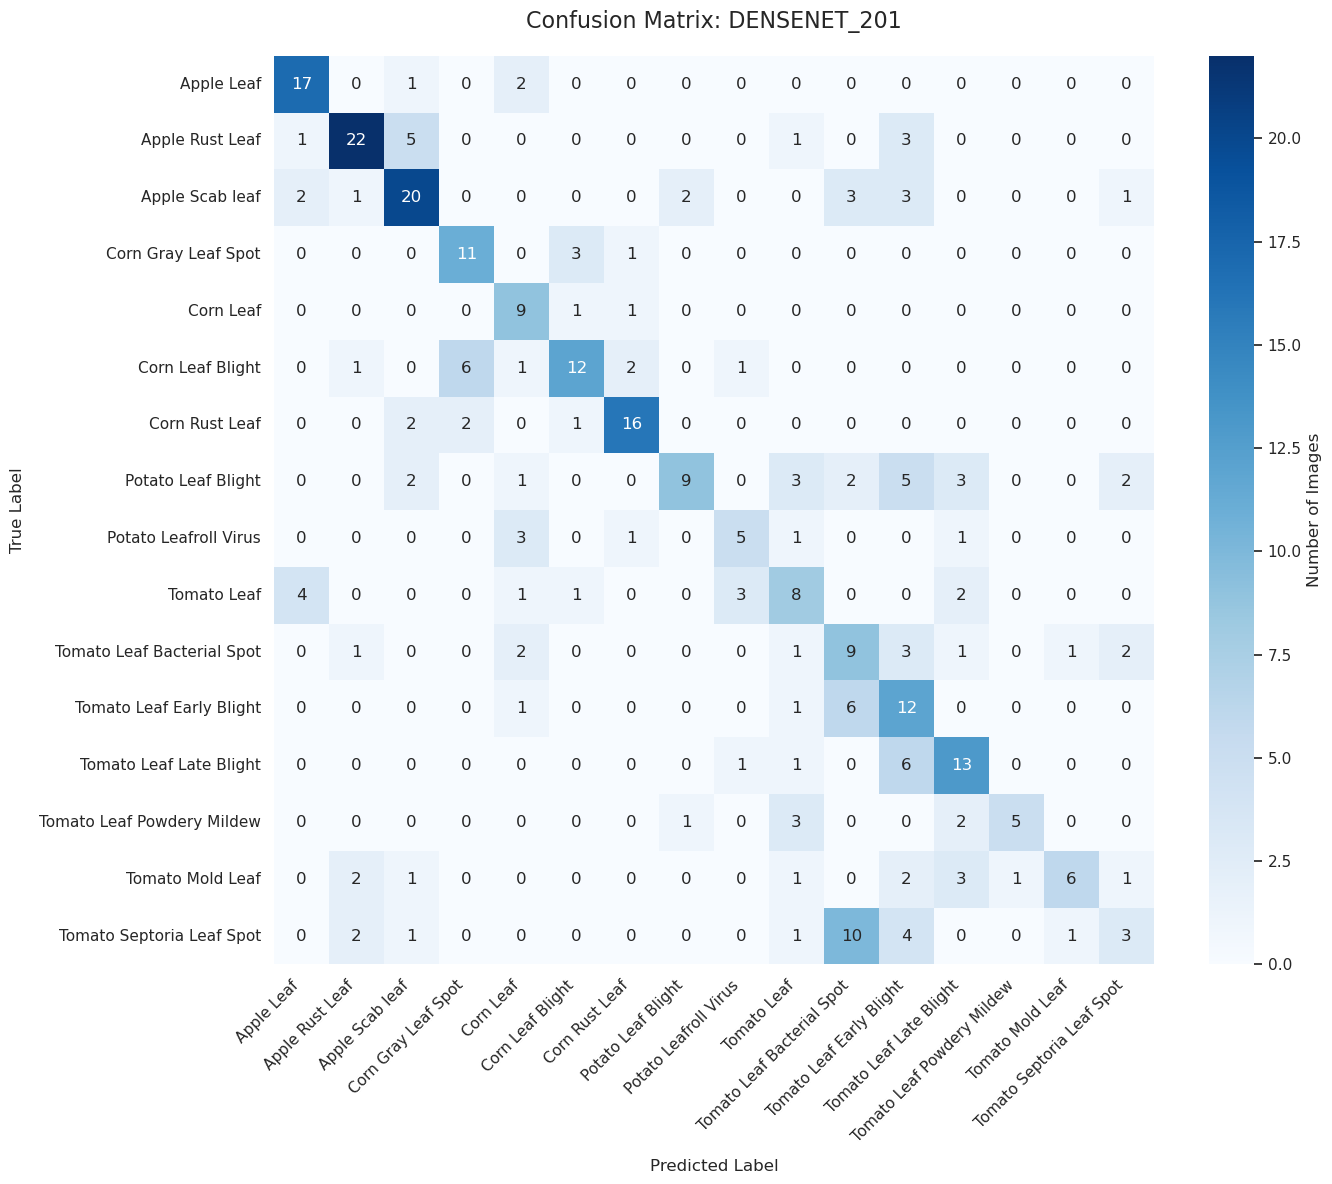

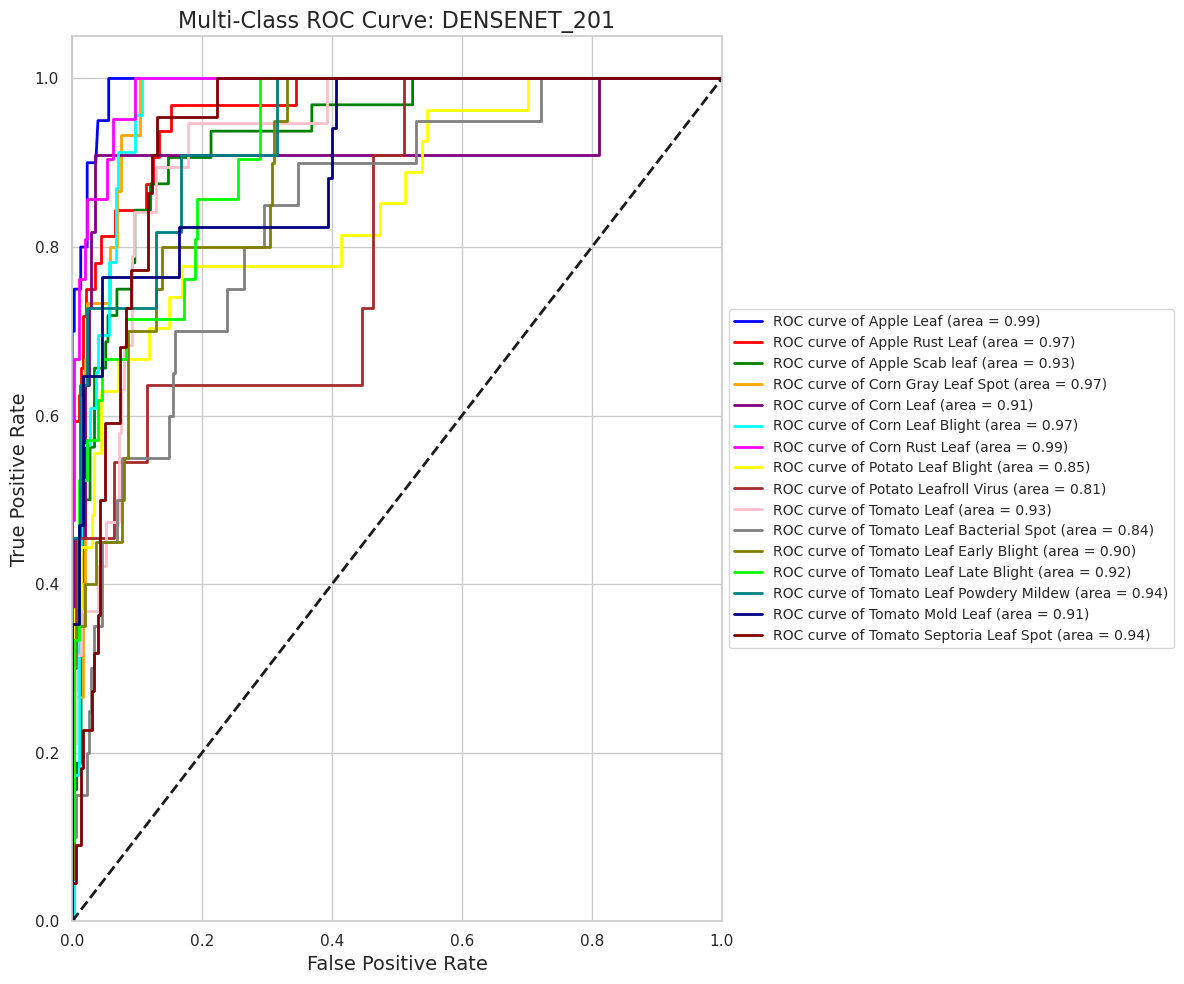

In [28]:
evaluate_model(model, test_loader, class_names, device)